# Project 1

## Utils

In [ ]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

rng = np.random.default_rng()

In [691]:
def sample_categorical(size, P):
    cdf = np.cumsum(P, axis = 1) # cumulative sum of the rows of P 
    u = rng.random(size = size)[:,None] # sample N variables from uniform
    return np.argmax(u<cdf, axis = 1) # return the first index for which cdf > u to sample from the categorical distributions

def make_transition_matrix(Q):
    N = len(Q)
    T = np.zeros((N,N))
    for i in range(N-1):
        for j in range(N):
            if i != j :
                T[i][j] =  -Q[i][j]/Q[i][i]
    T[N-1][N-1] = 1
    return T

## Part 3

### Task 12

In [634]:
def simulate_cancer_continuous_timeseries(Q = Q, N = N):
    Women = np.zeros(N,dtype=int) # states of the women at t=0
    Deaths = 0
    t = np.zeros(N)
    timeseries = np.zeros((N,4)) # careful
    scales = -1/np.diag(Q)
    T = make_transition_matrix(Q)
    while Deaths < N :
        alive_idx = np.where(Women < 4)[0]
        # sample sojourn time in current state for all the women
        t[alive_idx] += rng.exponential(scale=scales[Women[alive_idx]])
        # sample new state for all the women 
        Women[alive_idx] = sample_categorical(len(alive_idx), T[Women[alive_idx]])
        
        # Update transitions to state i+2
        for i in range(1,5):
            new_state_i_mask = (Women == i) & (timeseries[:,i-1] == 0)
            if np.any(new_state_i_mask):
                timeseries[new_state_i_mask,i-1] = t[new_state_i_mask]
                if i == 4 :
                    Deaths += np.sum(new_state_i_mask)
            
    return timeseries



In [635]:
timeseries = simulate_cancer_continuous_timeseries()

/var/folders/gs/x_qjskpx3cx1q_09m7tx94500000gn/T/ipykernel_13988/2263041135.py:6: RuntimeWarning: divide by zero encountered in divide
  scales = -1/np.diag(Q)


In [636]:
Death_times = timeseries[:,3]
chi2_stat, p_value = chi2_test_continuous(bin_width=50, results=Death_times)

print("--- Corrected Chi-Squared Test Results ---")
print(f"Chi2 Statistic : {chi2_stat:.4f}")
print(f"p-value        : {p_value:.4f}")

--- Corrected Chi-Squared Test Results ---
Chi2 Statistic : 16.8596
p-value        : 0.3947


The time series can be reconstructed from this array using the times a woman jumps from a state to another

In [637]:
def make_time_series(ts_array):
    N = len(ts_array)
    ts = {w : [] for w in range(N)}
    for w in range(N):
        state = 0
        t = 0
        states_w_idx = np.array(np.where(ts_array[w,:] != 0))[0] + 1
        #print(ts_array[w])
        i = 0
        while state < 4:
            # have we passed to the next state ?
            if ts_array[w][states_w_idx[i]-1] < t :
                state = states_w_idx[i]
                ts[w].append(states_w_idx[i])
                i += 1 # update the next state
            else :
                ts[w].append(state)
            t += 48
    return ts

Doctor_ts = make_time_series(timeseries)
print(Doctor_ts[50])

[0, 0, 0, np.int64(1), np.int64(3), np.int64(3), np.int64(4)]


### Task 13

In [658]:
p_dead = 0.2
N_women = len(Doctor_ts)
Q_guess = np.zeros((5,5))
for j in range(5):
    for i in range(j+1):
        if i == j:
            Q_guess[i][j] = -1 - p_dead
        elif i != 4 and j != 4 :
            Q_guess[i][j] = 1/((3-i))
        elif i != 4 and j == 4 :
            Q_guess[i][j] = p_dead    
Q_guess[3][4] = 1 + p_dead
Q_guess = Q_guess/300
print(Q_guess)

Q = np.array([
    [-0.0085,  0.005,   0.0025,  0.0,     0.001 ],
    [ 0.0,    -0.014,   0.005,   0.004,   0.005 ],
    [ 0.0,     0.0,    -0.008,   0.003,   0.005 ],
    [ 0.0,     0.0,     0.0,    -0.009,   0.009 ],
    [ 0.0,     0.0,     0.0,     0.0,     0.0   ]
])


[[-0.004       0.00111111  0.00111111  0.00111111  0.00066667]
 [ 0.         -0.004       0.00166667  0.00166667  0.00066667]
 [ 0.          0.         -0.004       0.00333333  0.00066667]
 [ 0.          0.          0.         -0.004       0.004     ]
 [ 0.          0.          0.          0.         -0.004     ]]


In [687]:
def simulate_segment(Q, start_state, end_state, span=48):
    
    # Create local tracking variables for this specific attempt
    local_sojourn = np.zeros(5)
    local_N = np.zeros((5, 5))
    
    current_state = start_state
    t = 0
    rates = -np.diag(Q)
    
    # Pre-calculate jump probabilities for each state
    # Avoid division by zero for the absorbing state (death)
    jump_probs = np.zeros_like(Q)
    for i in range(4): 
        if rates[i] > 0:
            jump_probs[i] = Q[i] / rates[i]
            jump_probs[i, i] = 0 # Cannot jump to itself
            
    while t < span:
        # If the woman enters the absorbing state (State 5 / index 4), she stays there
        if current_state == 4:
            local_sojourn[current_state] += (span - t)
            break
            
        # Sample time until next transition
        delta = np.random.exponential(scale=1/rates[current_state])
        
        if t + delta > span:
            # No transition happens before the 48-month mark ends
            local_sojourn[current_state] += (span - t)
            break
        else:
            # Transition happens
            local_sojourn[current_state] += delta
            # Sample next state based on conditional jump probabilities
            next_state_options = range(5)
            new_state = np.random.choice(next_state_options, p=jump_probs[current_state])
            
            local_N[current_state][new_state] += 1
            current_state = new_state
            t += delta

    # Validate if the simulated ending state matches the doctor's observation
    if current_state == end_state:
        return True, local_sojourn, local_N
    return False, None, None

In [688]:
def plot_convergence(history, tolerance):
    
    plt.figure(figsize=(9, 5))
    
    # Plot the difference values across iterations
    iterations = np.arange(1, len(history) + 1)
    plt.plot(iterations, history, marker='o', color='#1f77b4', linewidth=2, label=r'$||Q^{(k)} - Q^{(k+1)}||_{\infty}$')
    
    # Draw a horizontal baseline representing your convergence threshold target
    plt.axhline(y=tolerance, color='r', linestyle='--', alpha=0.7, label=f'Tolerance Threshold ({tolerance})')
    
    # Use log-scale for the y-axis if the differences span across multiple scales
    if max(history) / min(history) > 10:
        #plt.yscale('log')
        plt.ylabel('Matrix Difference (Log Scale)')
    else:
        plt.ylabel('Matrix Difference')
        
    plt.xlabel('Iteration (k)')
    plt.grid(True, which="both", linestyle=':', alpha=0.5)
    plt.xticks(iterations)  # Ensures integer steps on the x-axis
    plt.legend(frameon=True, facecolor='white', edgecolor='none')
    plt.tight_layout()
    plt.show()

In [689]:
def step_k(Q, Doctor_ts):
    N_women = len(Doctor_ts)
    Sojourn = np.zeros(5)
    N_matrix = np.zeros((5, 5))

    for w in range(N_women):
        woman_profile = Doctor_ts[w]
        # Reconstruct segments between each consecutive pair of observations
        for current_step in range(len(woman_profile) - 1):
            start_state = woman_profile[current_step]
            end_state = woman_profile[current_step + 1]
            
            accepted = False
            while not accepted:
                accepted, local_sojourn, local_N = simulate_segment(Q, start_state, end_state, span=48)
                
            # ONLY update global parameters if the entire segment was successful
            Sojourn += local_sojourn
            N_matrix += local_N

    Q_new = np.zeros((5, 5))
    
    # Update for non-absorbing states (indices 0 to 3)
    for i in range(4):
        if Sojourn[i] > 0:
            for j in range(5):
                if i != j:
                    Q_new[i, j] = N_matrix[i, j] / Sojourn[i]
        
        # Set diagonal element so row sum equals 0
        Q_new[i, i] = -np.sum(Q_new[i])
        
    # State 5 (index 4) is absorbing; its entire row remains 0
    Q_new[4, 4] = 0.0

    return Q_new

In [ ]:
def run_em_algorithm(Q_initial, Doctor_ts, tolerance=1e-3, max_iterations=100):
    
    Q_k = np.copy(Q_initial)
    converged = False
    iteration = 0
    
    # List to store the difference history for the convergence curve
    history = []
    
    print("Starting EM Algorithm Optimization...")
    print("-" * 50)
    
    while not converged and iteration < max_iterations:
        # 1. Compute Q^(k+1) from the current Q^(k)
        Q_next = step_k(Q_k, Doctor_ts)
        
        # 2. Calculate the difference using the matrix infinity norm 
        diff = np.max(np.sum(np.abs(Q_next - Q_k), axis=1))
        
        # Append to our tracking history
        history.append(diff)
        
        print(f"Iteration {iteration+1:02d} | Matrix Diff: {diff:.6f}")
        
        # 3. Check convergence criterion 
        if diff < tolerance:
            converged = True
            print("-" * 50)
            print(f" Convergence reached after {iteration+1} iterations!")
        else:
            # Update matrix for the next iteration
            Q_k = np.copy(Q_next)
            iteration += 1
            
    if not converged:
        print("-" * 50)
        print("Warning: Maximum iterations reached without explicit convergence.")
    
    # 4. Plot the convergence curve cleanly
    plot_convergence(history, tolerance)
        
    return Q_k

Starting EM Algorithm Optimization...
--------------------------------------------------
Iteration 01 | Matrix Diff: 0.017079
Iteration 02 | Matrix Diff: 0.004244
Iteration 03 | Matrix Diff: 0.001908
Iteration 04 | Matrix Diff: 0.001363
Iteration 05 | Matrix Diff: 0.000422
--------------------------------------------------
 Convergence reached after 5 iterations!


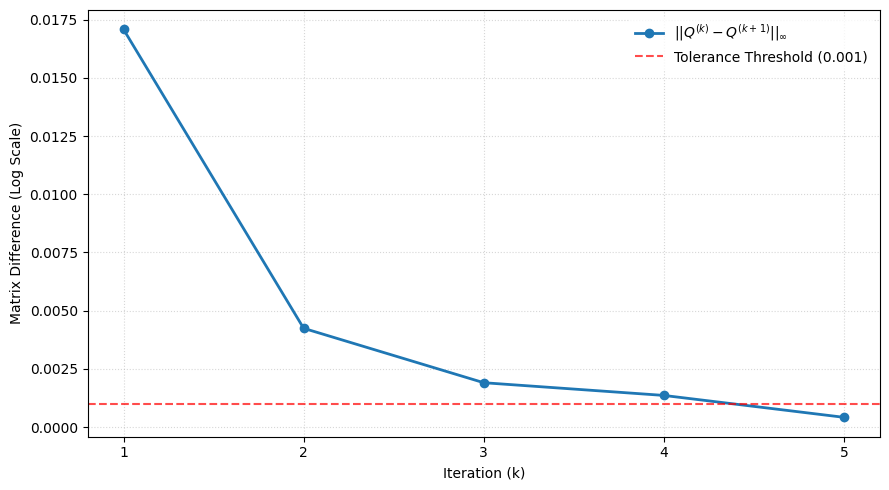

In [685]:
Q_final = run_em_algorithm(Q_initial=Q_guess,
                           Doctor_ts=Doctor_ts,
                           tolerance = 0.001,
                           max_iterations=1000)

In [659]:
print(Q_final)
print(Q)

[[-0.00808672  0.00575774  0.00198125  0.          0.00034773]
 [ 0.         -0.01540838  0.00805045  0.00374389  0.00361404]
 [ 0.          0.         -0.0085321   0.00439742  0.00413468]
 [ 0.          0.          0.         -0.01066562  0.01066562]
 [ 0.          0.          0.          0.          0.        ]]
[[-0.0085  0.005   0.0025  0.      0.001 ]
 [ 0.     -0.014   0.005   0.004   0.005 ]
 [ 0.      0.     -0.008   0.003   0.005 ]
 [ 0.      0.      0.     -0.009   0.009 ]
 [ 0.      0.      0.      0.      0.    ]]


Let's compare the result with the true rate matrix

In [686]:
print(np.max(np.abs(Q_final-Q)))

0.0036549545518427913


While the original distance between $Q^{(0)}$ and $Q$ was :

In [690]:
print(np.max(np.abs(Q_final-Q_guess)))

0.011953535629143055
